# Clean plotting notebook

This notebook refactors the original plotting workflow into reusable functions so the figures share a consistent style and are automatically saved to:

- `pdf/`
- `svg/`
- `png/`

It assumes the CSV file(s) referenced below live alongside this notebook unless you change the paths in the configuration cell.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

In [2]:
# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
BASE_DIR = Path(".")
CSV_MAIN = BASE_DIR / "compariosn_mix.csv"          # original filename kept intentionally
CSV_ALT = BASE_DIR / "compariosn_mix2.csv"          # optional alternate file if needed

OUT_PDF = BASE_DIR / "pdf"
OUT_SVG = BASE_DIR / "svg"
OUT_PNG = BASE_DIR / "png"

for out_dir in (OUT_PDF, OUT_SVG, OUT_PNG):
    out_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------
# Shared constants
# ------------------------------------------------------------------
STATUS_ORDER = ["Unloaded", "Near L.U", "Loaded"]
STATUS_STYLES = {
    "Loaded": {"marker": "o", "color": "#0072B2"},
    "Near L.U": {"marker": "s", "color": "0.55"},
    "Unloaded": {"marker": "^", "color": "#F2A7A7"},
}
CLASS_COLORS = {
    "Loaded": "#0072B2",
    "Near L.U": "0.55",
    "Unloaded": "#F2A7A7",
}
MODEL_PALETTE = {
    "Droplet-Film model": "#0072B2",
    "Qlattice model": "#CC79A7",
    "TabPFN model": "#7F7F7F",
}

MODEL_TEXTURE = {
    "Droplet-Film model": "//",
    "Qlattice model": "xx",
    "TabPFN model": "#..",
}
LITERATURE_PERFORMANCE = pd.DataFrame({
    "Model": [
        "Turner et al. (1969)",
        "Li et al. (2001)",
        "Chen et al. (2016)",
        "Shekhar et al. (2017)",
        "Liu et al. (2018)",
        "Abhulimen et al. (2022)",
        "Qlattice",
        "TabPFN model",
        "Droplet-Film model",
    ],
    "Unloaded": [53/53, 53/53, 53/53, 44/53, 42/53, 44/53, 24/53, 44/53, 43/53],
    "Near L.U": [2/6, 3/6, 0/6, 0/6, 0/6, 5/6, 0/6, 5/6, 5/6],
    "Loaded": [12/31, 5/31, 0/31, 18/31, 31/31, 29/31, 31/31, 31/31, 31/31],
})
CLASS_COUNTS = {"Unloaded": 53, "Near L.U": 6, "Loaded": 31}

In [3]:
def set_plot_style(
    *,
    family="sans-serif",
    sans_serif=("Arial",),
    serif=("Times New Roman", "Times", "STIXGeneral"),
    mathtext="dejavusans",
    font_size=14,
    axes_labelsize=None,
    axes_titlesize=None,
    tick_labelsize=None,
):
    """Apply a consistent publication-style matplotlib theme."""
    plt.rcParams.update({
        "font.family": family,
        "font.sans-serif": list(sans_serif),
        "font.serif": list(serif),
        "mathtext.fontset": mathtext,
        "font.size": font_size,
        "axes.labelsize": axes_labelsize or font_size,
        "axes.titlesize": axes_titlesize or font_size,
        "axes.linewidth": 0.8,
        "xtick.labelsize": tick_labelsize or max(font_size - 1, 8),
        "ytick.labelsize": tick_labelsize or max(font_size - 1, 8),
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.size": 2.5,
        "ytick.minor.size": 2.5,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
    })


def save_figure(fig, stem):
    """Save a figure with the same filename stem into pdf/svg/png folders."""
    fig.savefig(OUT_PDF / f"{stem}.pdf")
    fig.savefig(OUT_SVG / f"{stem}.svg")
    fig.savefig(OUT_PNG / f"{stem}.png")


def read_comparison_csv(path=CSV_MAIN):
    df = pd.read_csv(path)
    return df[df["Well status"].isin(STATUS_ORDER)].copy()


def apply_common_spines(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def apply_scaled_rate_format(ax, scale=1e4):
    formatter = FuncFormatter(lambda val, _: f"{val/scale:.0f}")
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)
    ax.set_xlabel(r"Gas Flow Rate ($\times 10^4$ m$^3$ day$^{-1}$)")
    ax.set_ylabel(r"Regressed Critical Rate ($\times 10^4$ m$^3$ day$^{-1}$)")

In [4]:
def plot_regime_parity(
    df,
    *,
    y_col,
    title,
    filename,
    xmax,
    delta,
    figsize=(4.5, 4.5),
    font_size=11,
    title_size=None,
    family="sans-serif",
    mathtext="dejavusans",
):
    """Parity-style regime plot with shared formatting and automatic exports."""
    set_plot_style(
        family=family,
        mathtext=mathtext,
        font_size=font_size,
        axes_labelsize=font_size,
        tick_labelsize=max(font_size - 1, 8),
    )

    xmin = 0
    x = np.linspace(xmin, xmax, 600)
    upper = x + delta
    lower = x - delta

    fig, ax = plt.subplots(figsize=figsize)

    # Regime bands
    ax.fill_between(x, np.clip(upper, xmin, xmax), xmax, color="#0072B2", alpha=0.10, zorder=1)
    ax.fill_between(x, np.clip(lower, xmin, xmax), np.clip(upper, xmin, xmax), color="0.55", alpha=0.20, zorder=1)
    ax.fill_between(x, xmin, np.clip(lower, xmin, xmax), color="#F2A7A7", alpha=0.22, zorder=1)

    # Reference lines
    ax.plot(x, x, color="black", linewidth=1.8, zorder=3)
    ax.plot(x, upper, linestyle="--", color="black", linewidth=1.4, zorder=3)
    ax.plot(x, lower, linestyle="--", color="black", linewidth=1.4, zorder=3)

    # Points
    for status in ["Loaded", "Near L.U", "Unloaded"]:
        subset = df[df["Well status"] == status]
        if subset.empty:
            continue
        style = STATUS_STYLES[status]
        ax.scatter(
            subset["Test flow rate"],
            subset[y_col],
            s=25,
            marker=style["marker"],
            facecolor=style["color"],
            edgecolor="black",
            linewidth=0.6,
            zorder=5,
        )

    ax.set_xlim(0, 350000)
    ax.set_ylim(0, 350000)
    ax.set_aspect("equal", adjustable="box")
    ax.tick_params(length=4, width=0.8, top=True, right=True)
    ax.tick_params(which="minor", length=2.5, width=0.6)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.set_title(title, fontsize=title_size or (font_size + 1), pad=6)
    apply_scaled_rate_format(ax)
    apply_common_spines(ax)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    return fig, ax

In [5]:
def plot_grouped_per_class_accuracy(
    per_class_df,
    *,
    palette,
    filename,
    figsize=(7, 5),
    ylabel="Classification Accuracy (%)",
    legend_anchor=(1.02, 1.0),
    family="sans-serif",
    font_size=15,
    mathtext="dejavusans",
):
    set_plot_style(
        family=family,
        mathtext=mathtext,
        font_size=font_size,
        axes_labelsize=font_size,
        axes_titlesize=font_size,
        tick_labelsize=max(font_size - 1, 8),
    )

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(STATUS_ORDER))
    width = 0.15

    for i, model in enumerate(per_class_df.index):
        ax.bar(
            x + i * width,
            [per_class_df.loc[model, status] for status in STATUS_ORDER],
            width,
            label=model,
            color=palette[model],
            edgecolor="black",
            linewidth=0.6,
        )
    
    ax.set_xticks(x + width * (len(per_class_df.index) - 1) / 2)
    STATUS_ORDER[1] = "Near\n Loaded"
    ax.set_xticklabels(STATUS_ORDER)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val * 100:.0f}"))
     
      # ---- Minor ticks ----
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # one minor between majors
    ax.tick_params(which="major", length=5, width=0.8)
    ax.tick_params(which="minor", length=3, width=0.6)
    apply_common_spines(ax)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    STATUS_ORDER[1] = "Near L.U"
    return fig, ax
  

In [6]:
def plot_grouped_per_class_accuracy(
    per_class_df,
    *,
    palette,
    filename,
    figsize=(7, 5),
    ylabel="Classification Accuracy (%)",
    legend_anchor=(1.02, 1.0),
    family="sans-serif",
    font_size=15,
    mathtext="dejavusans",
):
    set_plot_style(
        family=family,
        mathtext=mathtext,
        font_size=font_size,
        axes_labelsize=font_size,
        axes_titlesize=font_size,
        tick_labelsize=max(font_size - 1, 8),
    )

    # 1. Filter out the middle class (Near Loaded / Near L.U)
    # We create a local list so we don't plot the second element
    filtered_status = [status for i, status in enumerate(STATUS_ORDER) if i != 1]
    
    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(filtered_status)) # Adjust x-axis length
    width = 0.15

    for i, model in enumerate(per_class_df.index):
        # 2. Only pull data for the statuses remaining in our filtered list
        plot_values = [per_class_df.loc[model, status] for status in filtered_status]
        
        ax.bar(
            x + i * width,
            plot_values,
            width,
            label=model,
            color=palette[model],
            edgecolor="black",
            linewidth=0.6,
        )
    
    # 3. Recalculate ticks to center labels under the new bar groups
    ax.set_xticks(x + width * (len(per_class_df.index) - 1) / 2)
    ax.set_xticklabels(filtered_status)
    
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda val, _: f"{val * 100:.0f}"))
     
    # ---- Minor ticks ----
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(which="major", length=5, width=0.8)
    ax.tick_params(which="minor", length=3, width=0.6)
    apply_common_spines(ax)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    
    return fig, ax

In [7]:
def plot_stacked_class_performance(
    df,
    *,
    filename,
    annotate_total_accuracy=False,
    annotate_segment_values=False,
    show_perfect_reference=False,
    xlabel="Correctly classified wells by operating regime",
    xlim=(0, 3.0),
    figsize=(10, 5),
    family="serif",
    font_size=15,
    mathtext="stix",
):
    set_plot_style(
        family=family,
        mathtext=mathtext,
        font_size=font_size,
        axes_labelsize=font_size,
        axes_titlesize=font_size,
        tick_labelsize=max(font_size - 2, 8),
    )

    fig, ax = plt.subplots(figsize=figsize)
    y = np.arange(len(df))
    left = np.zeros(len(df))

    for cls in ["Unloaded", "Near L.U", "Loaded"]:
        values = df[cls].values
        ax.barh(
            y,
            values,
            left=left,
            color=CLASS_COLORS[cls],
            edgecolor="black",
            linewidth=0.6,
            label=cls,
        )

        if annotate_segment_values:
            for i, v in enumerate(values):
                if v > 0.05:
                    ax.text(
                        left[i] + v / 2,
                        i,
                        f"{v * 100:.0f}%",
                        va="center",
                        ha="center",
                        fontsize=max(font_size - 2, 8),
                    )

        left += values

    if show_perfect_reference:
        ax.axvline(3.0, color="black", linestyle="--", linewidth=1.2)
        ax.text(3.02, -0.6, "Perfect classification (100%)", va="top", ha="left", fontsize=max(font_size - 3, 8))

    if annotate_total_accuracy:
        total_n = sum(CLASS_COUNTS.values())
        correct_predictions = sum(df[cls] * CLASS_COUNTS[cls] for cls in CLASS_COUNTS)
        total_accuracy = correct_predictions / total_n * 100
        for i, acc in enumerate(total_accuracy):
            ax.text(left[i] + 0.03, i, f"{acc:.1f}%", va="center", ha="left", fontsize=max(font_size - 3, 8))

    ax.set_yticks(y)
    ax.set_yticklabels(df["Model"])
    ax.set_xlim(*xlim)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    ax.legend(frameon=False, loc="upper right", fontsize=max(font_size - 2, 8))
    apply_common_spines(ax)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    return fig, ax

In [8]:
from matplotlib.ticker import AutoMinorLocator

def plot_cv_vs_test_accuracy(
    *,
    models,
    cv_mean,
    cv_std,
    test_accuracy,
    filename,
    figsize=(7, 5),
    family="sans-serif",
    font_size=15,
    mathtext="dejavusans",
):
    set_plot_style(
        family=family,
        mathtext=mathtext,
        font_size=font_size,
        axes_labelsize=font_size,
        axes_titlesize=font_size,
        tick_labelsize=max(font_size - 2, 8),
    )

    fig, ax = plt.subplots(figsize=figsize)
    x = np.arange(len(models))

    ax.bar(
        x,
        cv_mean,
        yerr=cv_std,
        capsize=6,
        color="#D9D9D9",
        edgecolor="black",
        linewidth=0.8,
        label="Cross-validation mean ± std",
    )

    ax.scatter(
        x,
        test_accuracy,
        color="#0072B2",
        s=80,
        zorder=3,
        label="Test set accuracy",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(models)

    ax.set_ylim(0, 100)
    ax.set_ylabel("Classification accuracy (%)")

    # ---- Minor ticks ----
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # one minor between majors
    ax.tick_params(which="major", length=5, width=0.8)
    ax.tick_params(which="minor", length=3, width=0.6)

    #ax.legend(frameon=False, loc="upper left", fontsize=max(font_size - 2, 8))
    apply_common_spines(ax)

    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()
    return fig, ax

## Load data

In [9]:
df_main = read_comparison_csv(CSV_MAIN)
df_main.head()

,Droplet-Film model,PySINDY model,XGBoost model,Liquid film model,Liquid droplet model,Unnamed: 5,Qcr,Well status,Qlattice model,Unnamed: 9,TabPFN model,Test flow rate
0,5394.233321,5.472529e+04,7682.307,29758.411950,27697.270602,NaN,1161.193156,Unloaded,100642.490011,NaN,12456.4950,10700.0
1,13173.147790,9.821493e+04,29766.854,113516.213555,10487.257810,NaN,5455.071593,Unloaded,115531.438195,NaN,9747.2840,52200.0
2,13146.148358,-2.178551e+06,48953.527,113281.777530,11088.169408,NaN,4633.392453,Unloaded,118687.780637,NaN,26606.0330,42100.0
3,32830.180326,3.246229e+04,33720.310,117035.964320,10194.450091,NaN,33331.601393,Unloaded,114214.710211,NaN,16677.4000,57100.0
4,10174.524101,1.169379e+05,4685.315,30191.459915,18436.227767,NaN,2439.685411,Unloaded,106459.819074,NaN,6658.9087,22400.0


In [10]:
test_set = pd.read_csv("./test_set.csv")

# Keep only rows in df_main where Qcr is NOT within 1e-3 of any test_set Qcr value
test_qcr_values = test_set['Qcr'].values

def is_close_to_any(val, reference, tol=1e-4):
    return np.any(np.abs(reference - val) < tol)

mask = df_main['Qcr'].apply(lambda x: is_close_to_any(x, test_qcr_values))

print(len(df_main['Qcr']))
df_test = df_main[mask]
print(len(df_test['Qcr']))

192
38


## Parity / operating-regime plots

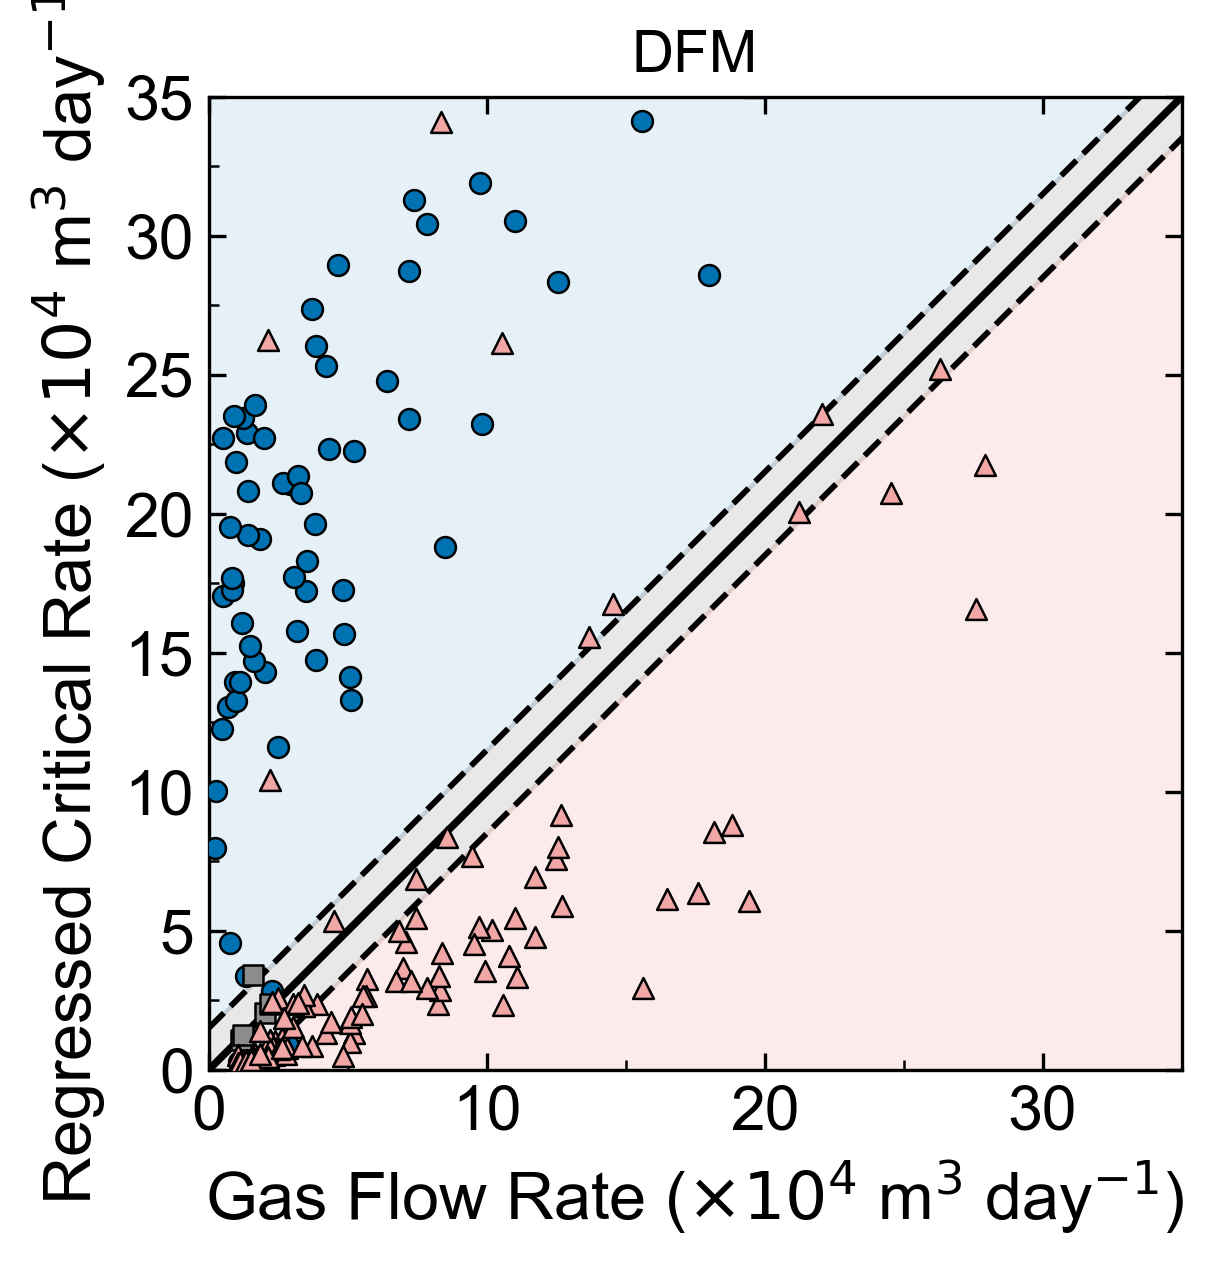

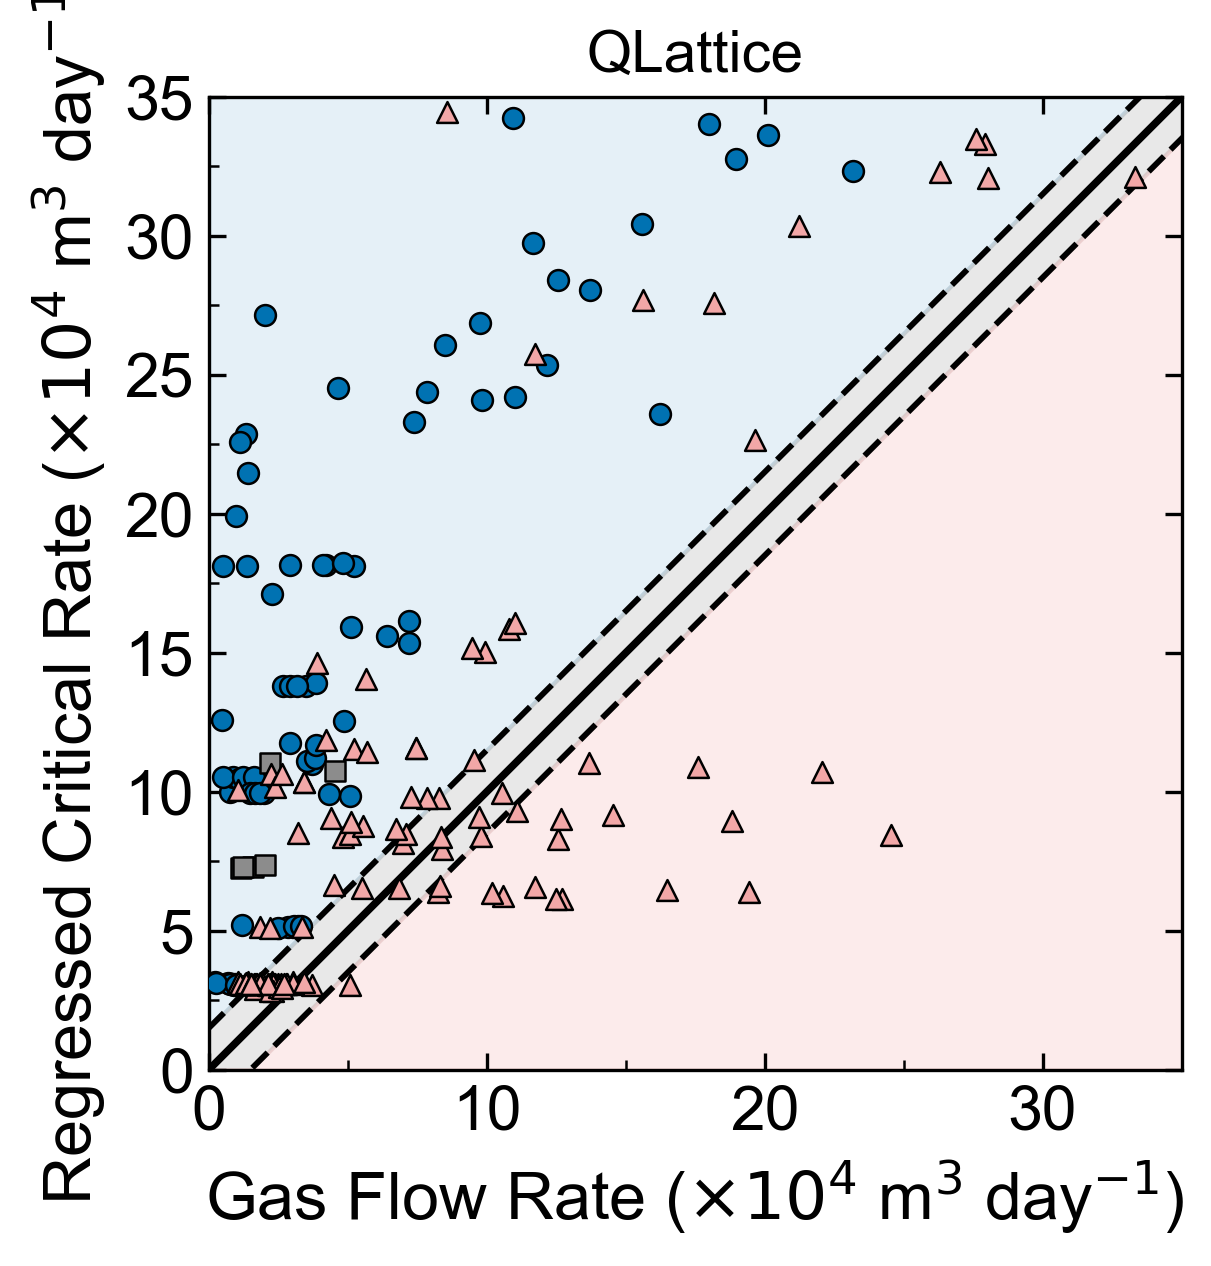

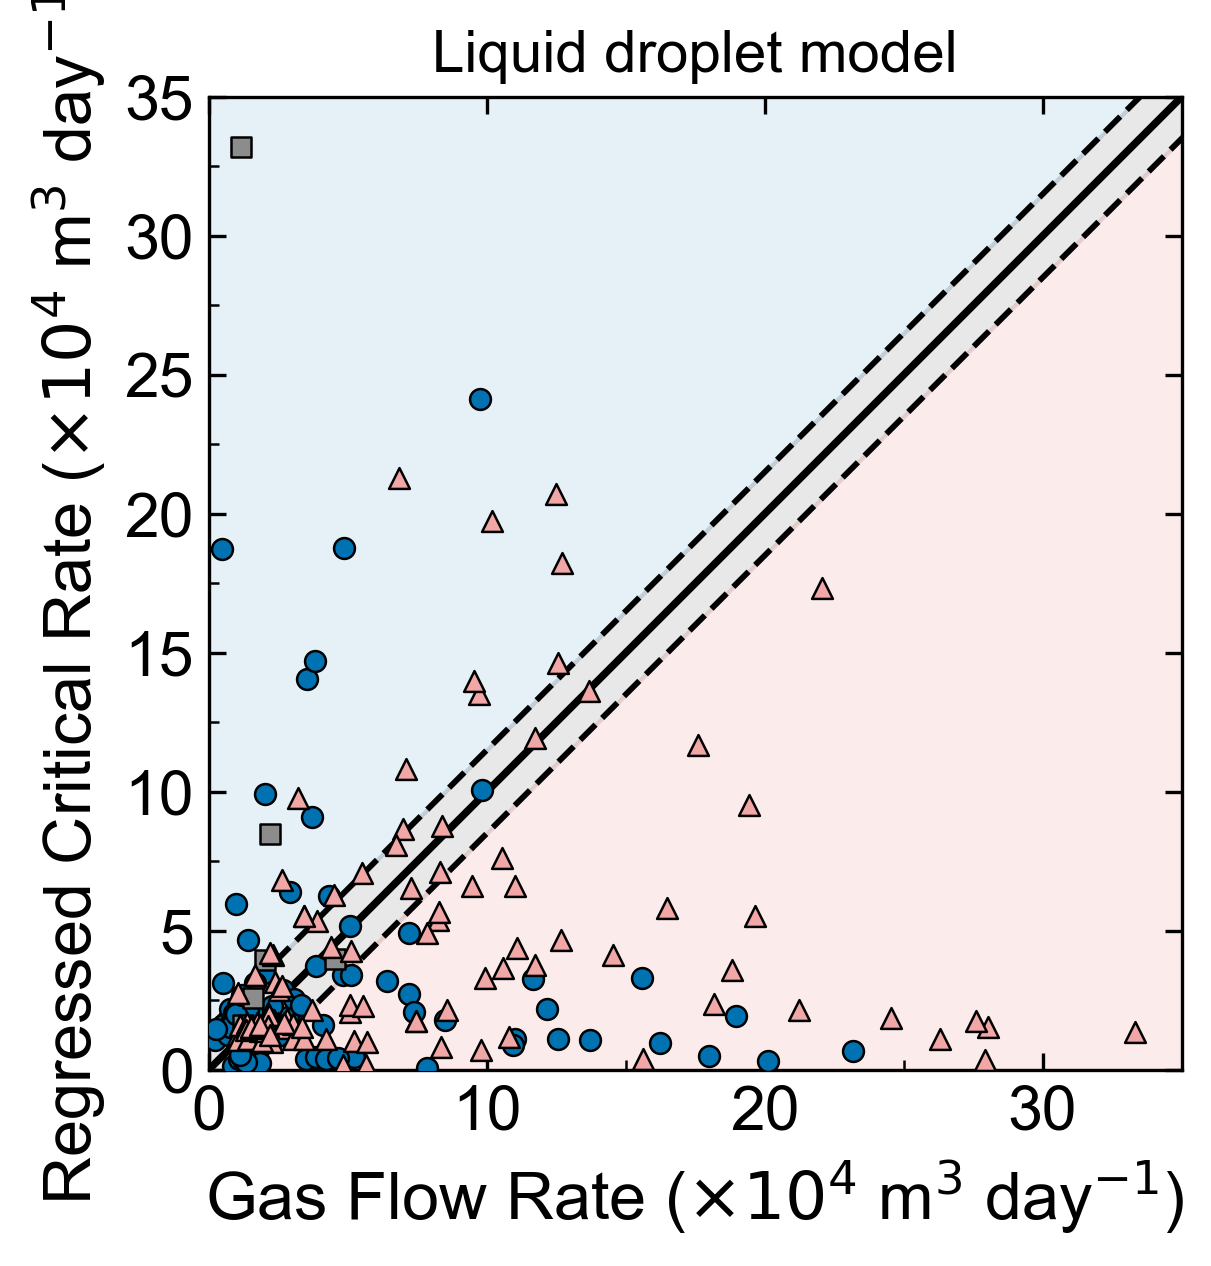

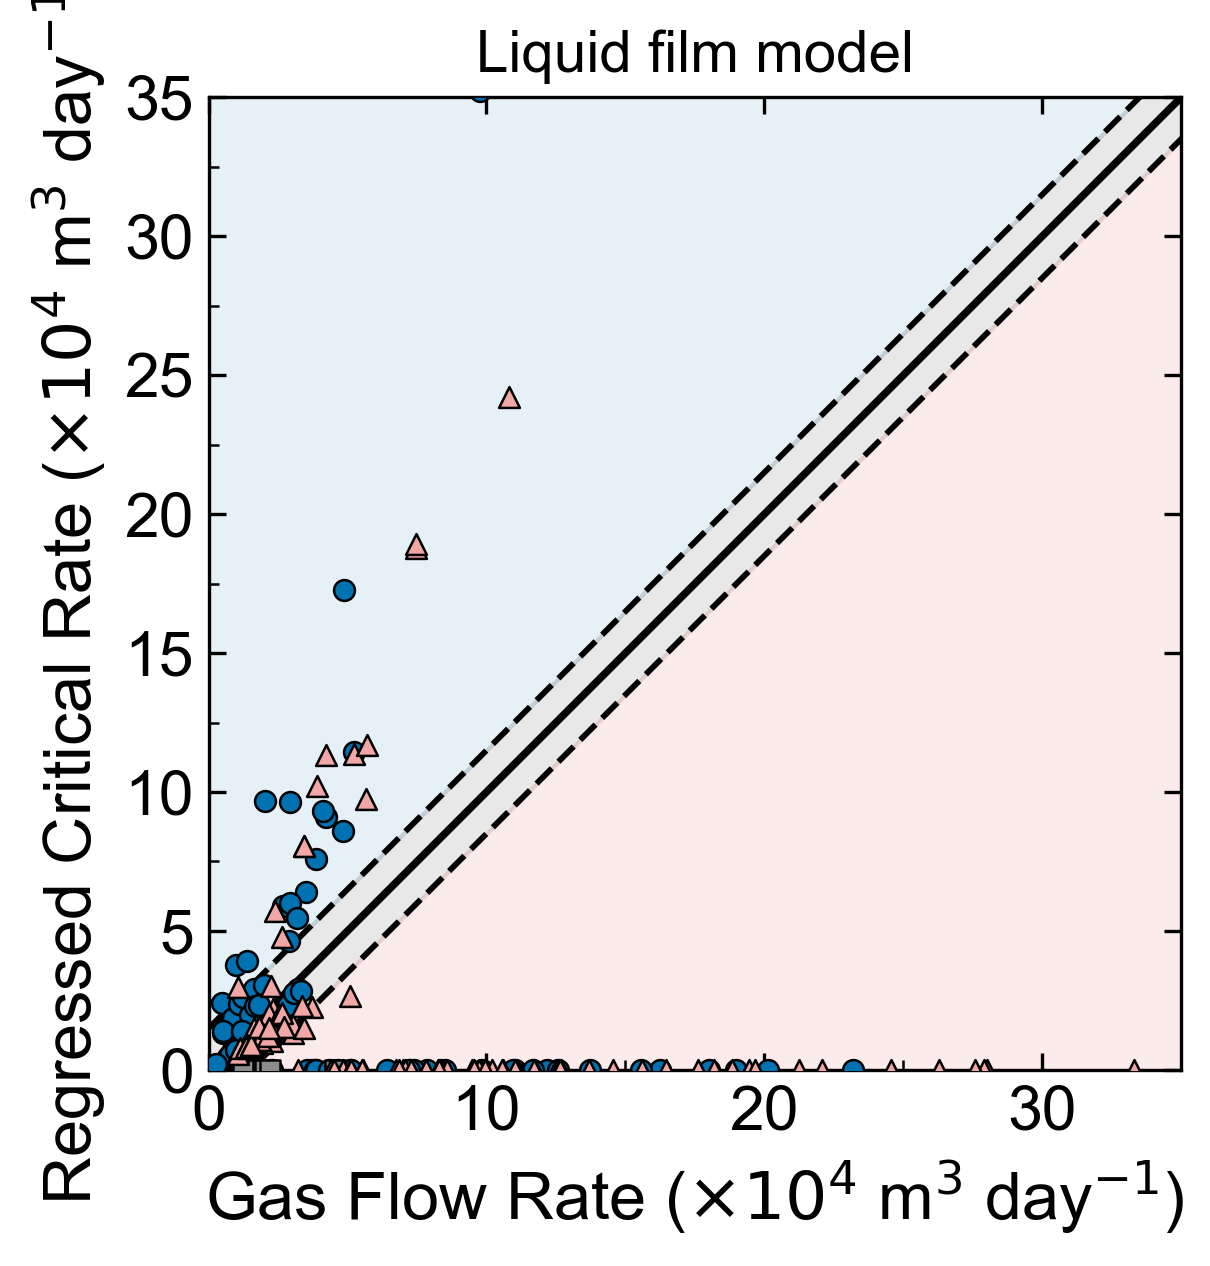

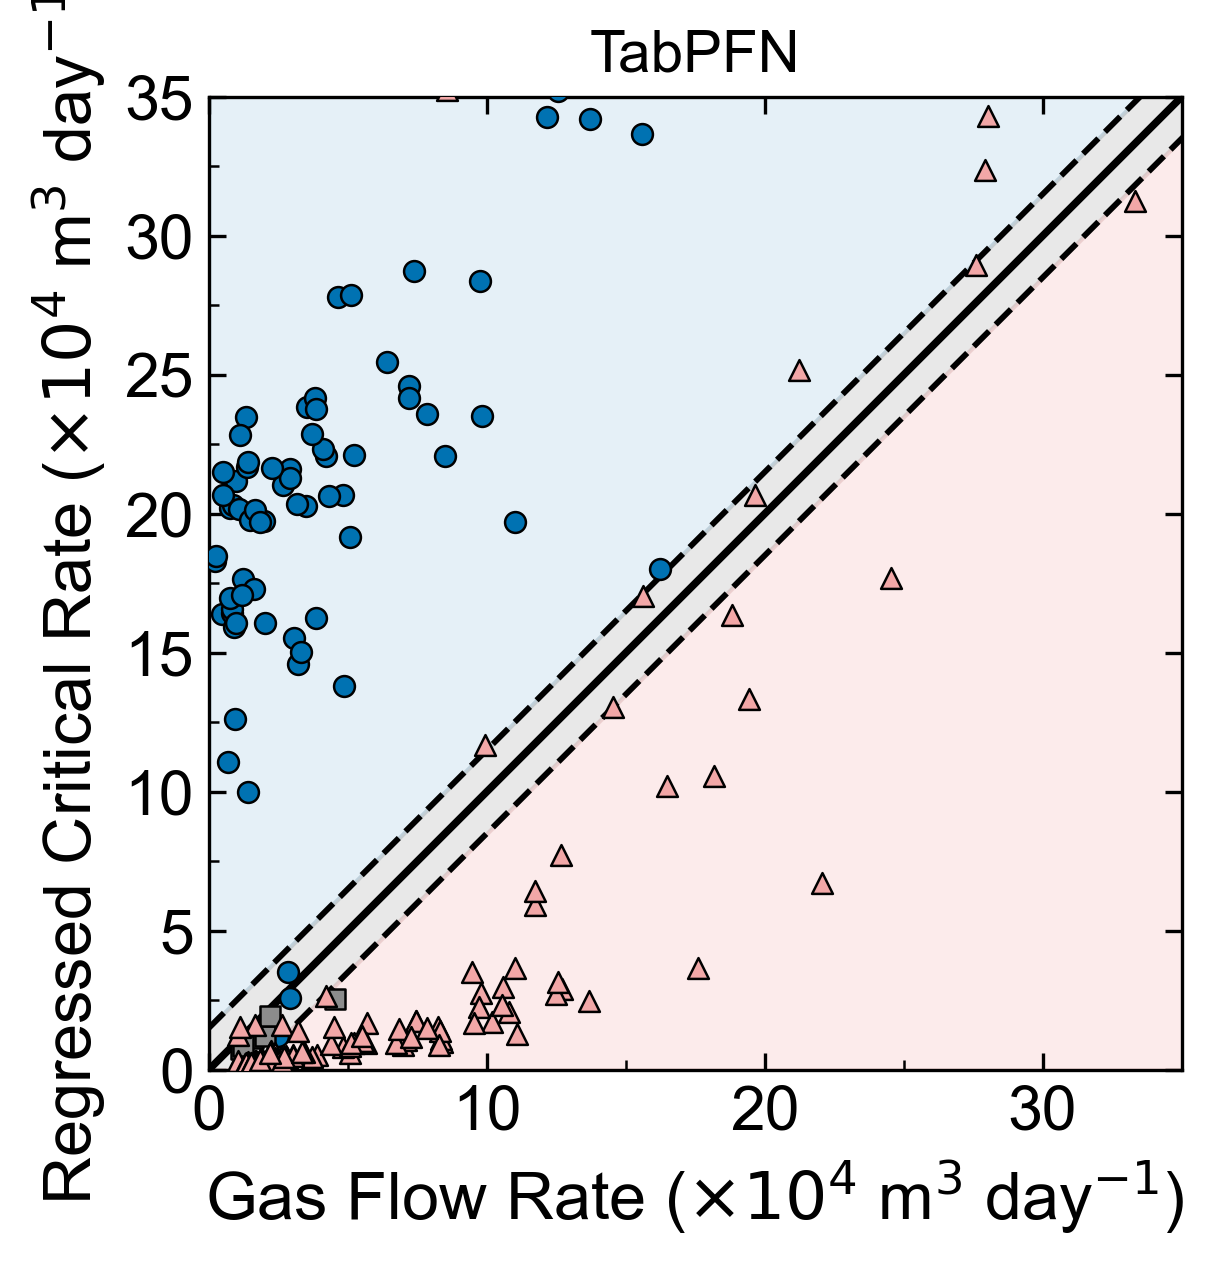

In [11]:
parity_specs = [
    {
        "y_col": "Droplet-Film model",
        "title": "DFM",
        "filename": "dft_new",
        "xmax": 360000,
        "delta": 15000,
        "font_size": 16,
        "title_size": 14,
    },

    {
        "y_col": "Qlattice model",
        "title": "QLattice",
        "filename": "qlattice_new",
        "xmax": 360000,
        "delta": 15000,
        "font_size": 16,
        "title_size": 14,
    },
    {
        "y_col": "Liquid droplet model",
        "title": "Liquid droplet model",
        "filename": "Liquid_droplet_model_new",
        "xmax": 360000,
        "delta": 15000,
        "font_size": 16,
        "title_size": 14,
    },
    {
        "y_col": "Liquid film model",
        "title": "Liquid film model",
        "filename": "Liquid_film_model_new",
        "xmax": 360000,
        "delta": 15000,
        "font_size": 16,
        "title_size": 14,
    },
    {
        "y_col": "TabPFN model",
        "title": "TabPFN",
        "filename": "tabPFN_new",
        "xmax": 380000,
        "delta": 15000,
        "font_size": 16,
        "title_size": 14,
    },
]

for spec in parity_specs:
    plot_regime_parity(df_main, **spec)

## Per-class accuracy from `compariosn_mix.csv`

In [12]:
def classify_with_near_lu(test_rate, critical_rate, delta):
    critical_rate = float(critical_rate)
    test_rate = float(test_rate)

    if critical_rate > test_rate + delta:
        physical_status = "Loaded"
    elif critical_rate < test_rate - delta:
        physical_status = "Unloaded"
    else:
        physical_status = "Near L.U"
    
    return physical_status 
    
def compute_per_class_accuracy(df, models, delta):
    """Compute per-class regime accuracy for each model column."""
    per_class_accuracy = {}

    for model in models:
        counts = {
            "Loaded": {"correct": 0, "total": 0},
            "Unloaded": {"correct": 0, "total": 0},
            "Near L.U": {"correct": 0, "total": 0},
        }

        for _, row in df.iterrows():
            true_status = row["Well status"]
            pred_status = classify_with_near_lu(
                test_rate=row["Test flow rate"],
                critical_rate=row[model],
                delta=delta,
            )

            if true_status == "Loaded":
                counts["Loaded"]["total"] += 1
                counts["Loaded"]["correct"] += int(pred_status == "Loaded")

            elif true_status == "Unloaded":
                counts["Unloaded"]["total"] += 1
                counts["Unloaded"]["correct"] += int(pred_status == "Unloaded")

            elif true_status == "Near L.U":
                counts["Near L.U"]["total"] += 1
                counts["Near L.U"]["correct"] += int(pred_status == "Near L.U")

        per_class_accuracy[model] = {
            status: (
                counts[status]["correct"] / counts[status]["total"]
                if counts[status]["total"] else np.nan
            )
            for status in STATUS_ORDER
        }

    return pd.DataFrame(per_class_accuracy).T


In [13]:
per_class_df = compute_per_class_accuracy(
    df_test,
    models=list(MODEL_PALETTE.keys()),
    delta=0.01,  # kept from original notebook for figure alignment
)
per_class_df

,Unloaded,Near L.U,Loaded
Droplet-Film model,0.782609,0.0,0.857143
Qlattice model,0.217391,0.0,1.000000
TabPFN model,0.782609,0.0,0.928571


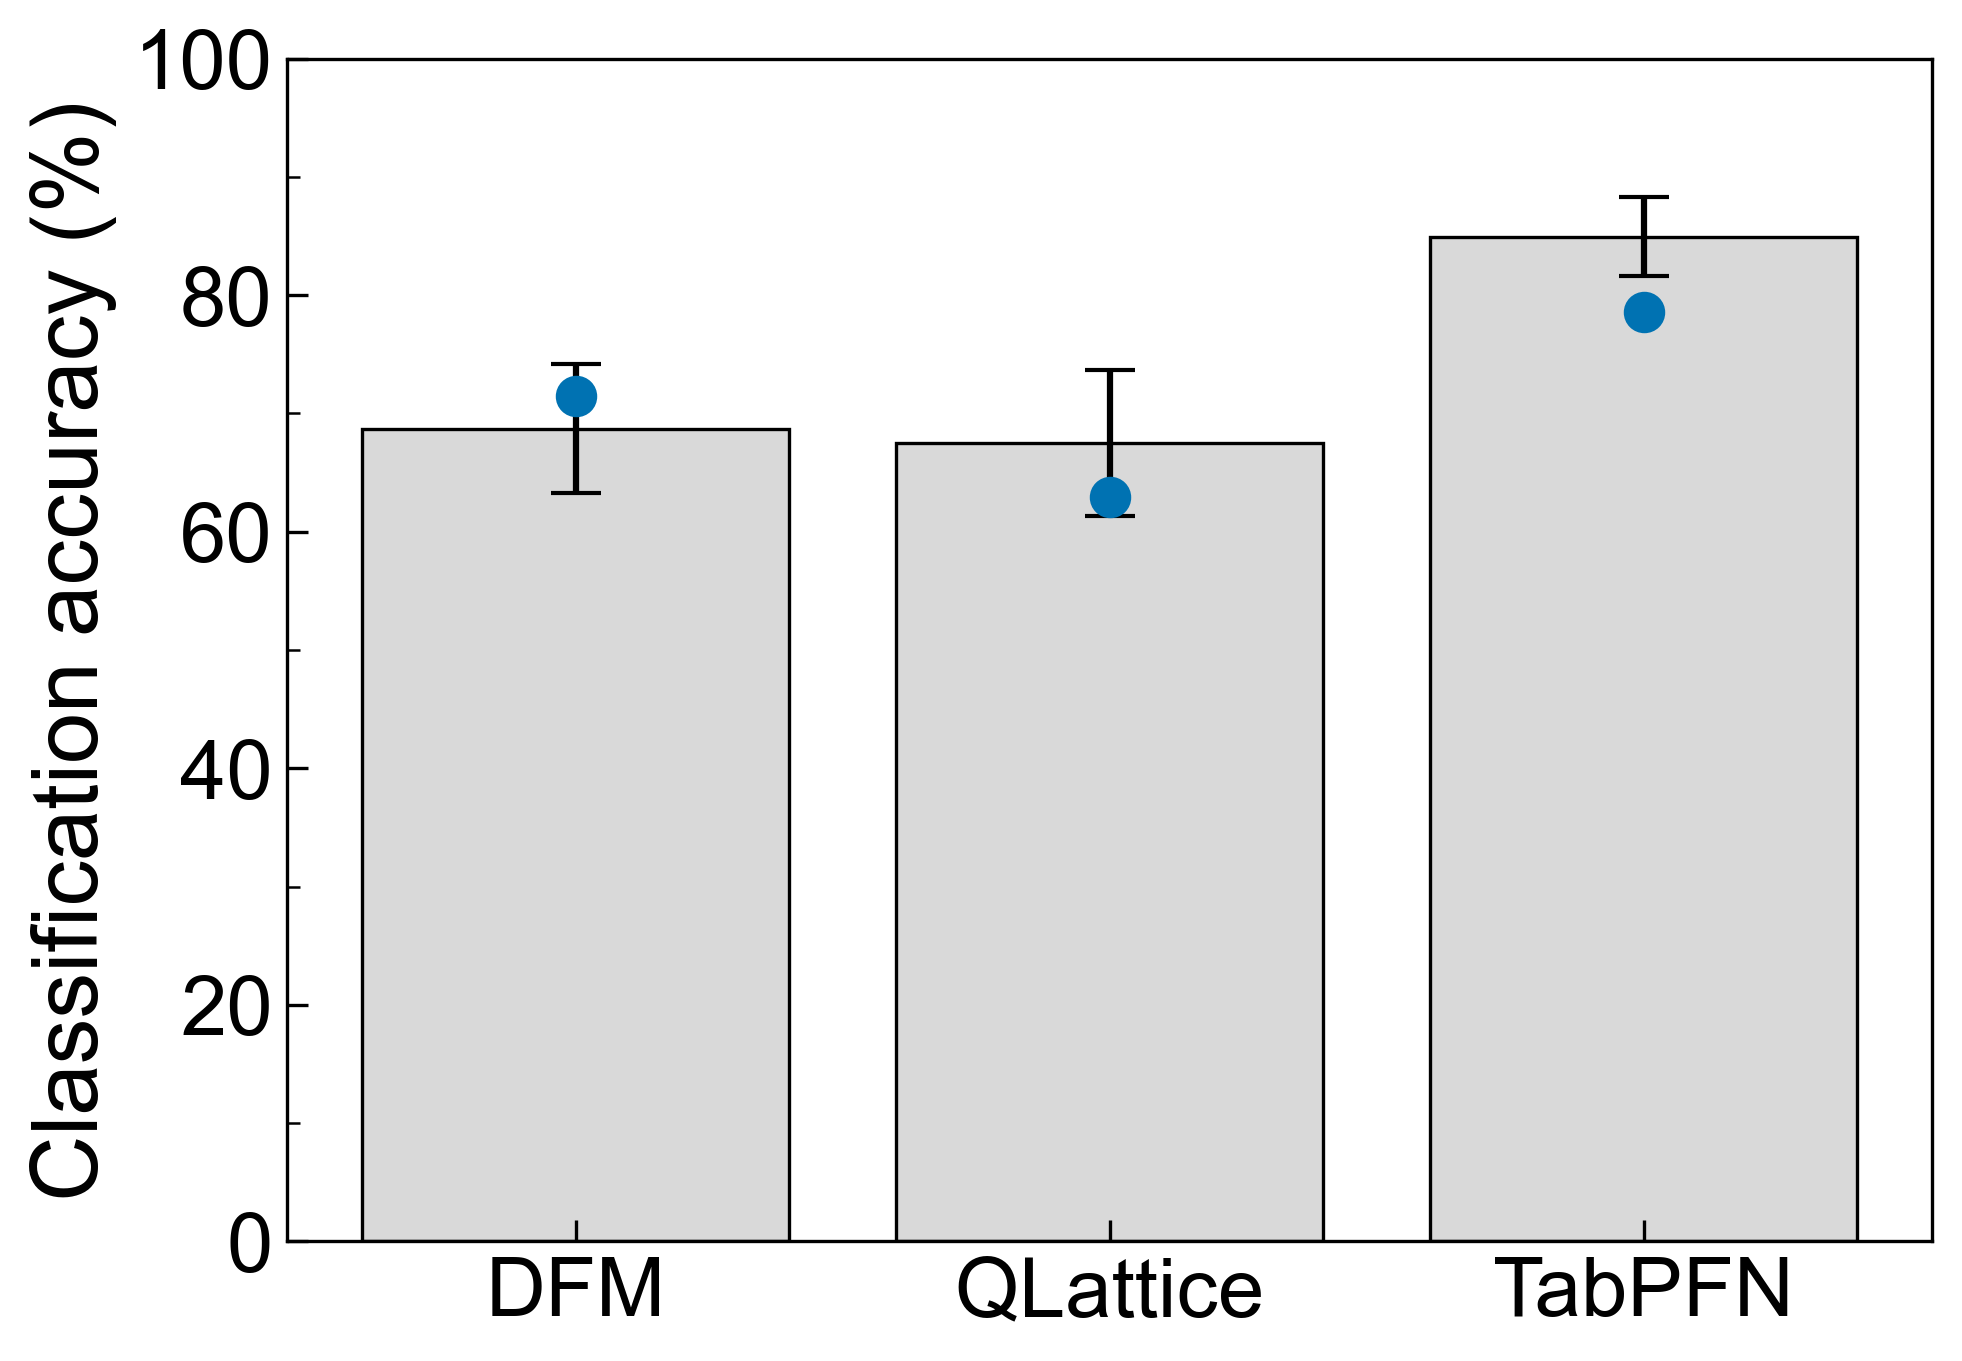

(<Figure size 2100x1500 with 1 Axes>,
 <Axes: ylabel='Classification accuracy (%)'>)

In [14]:
plot_cv_vs_test_accuracy(
    models=["DFM", "QLattice", "TabPFN"],
    cv_mean=np.array([68.70, 67.47, 84.94]),
    cv_std=np.array([5.44, 6.17, 3.32]),
    test_accuracy=np.array([71.43, 62.90, 78.57]),
    filename="model_accuracy_cv_vs_test",
    figsize=(7, 5),
    family="sans-serif",
    font_size=22,
    mathtext="dejavusans",
)

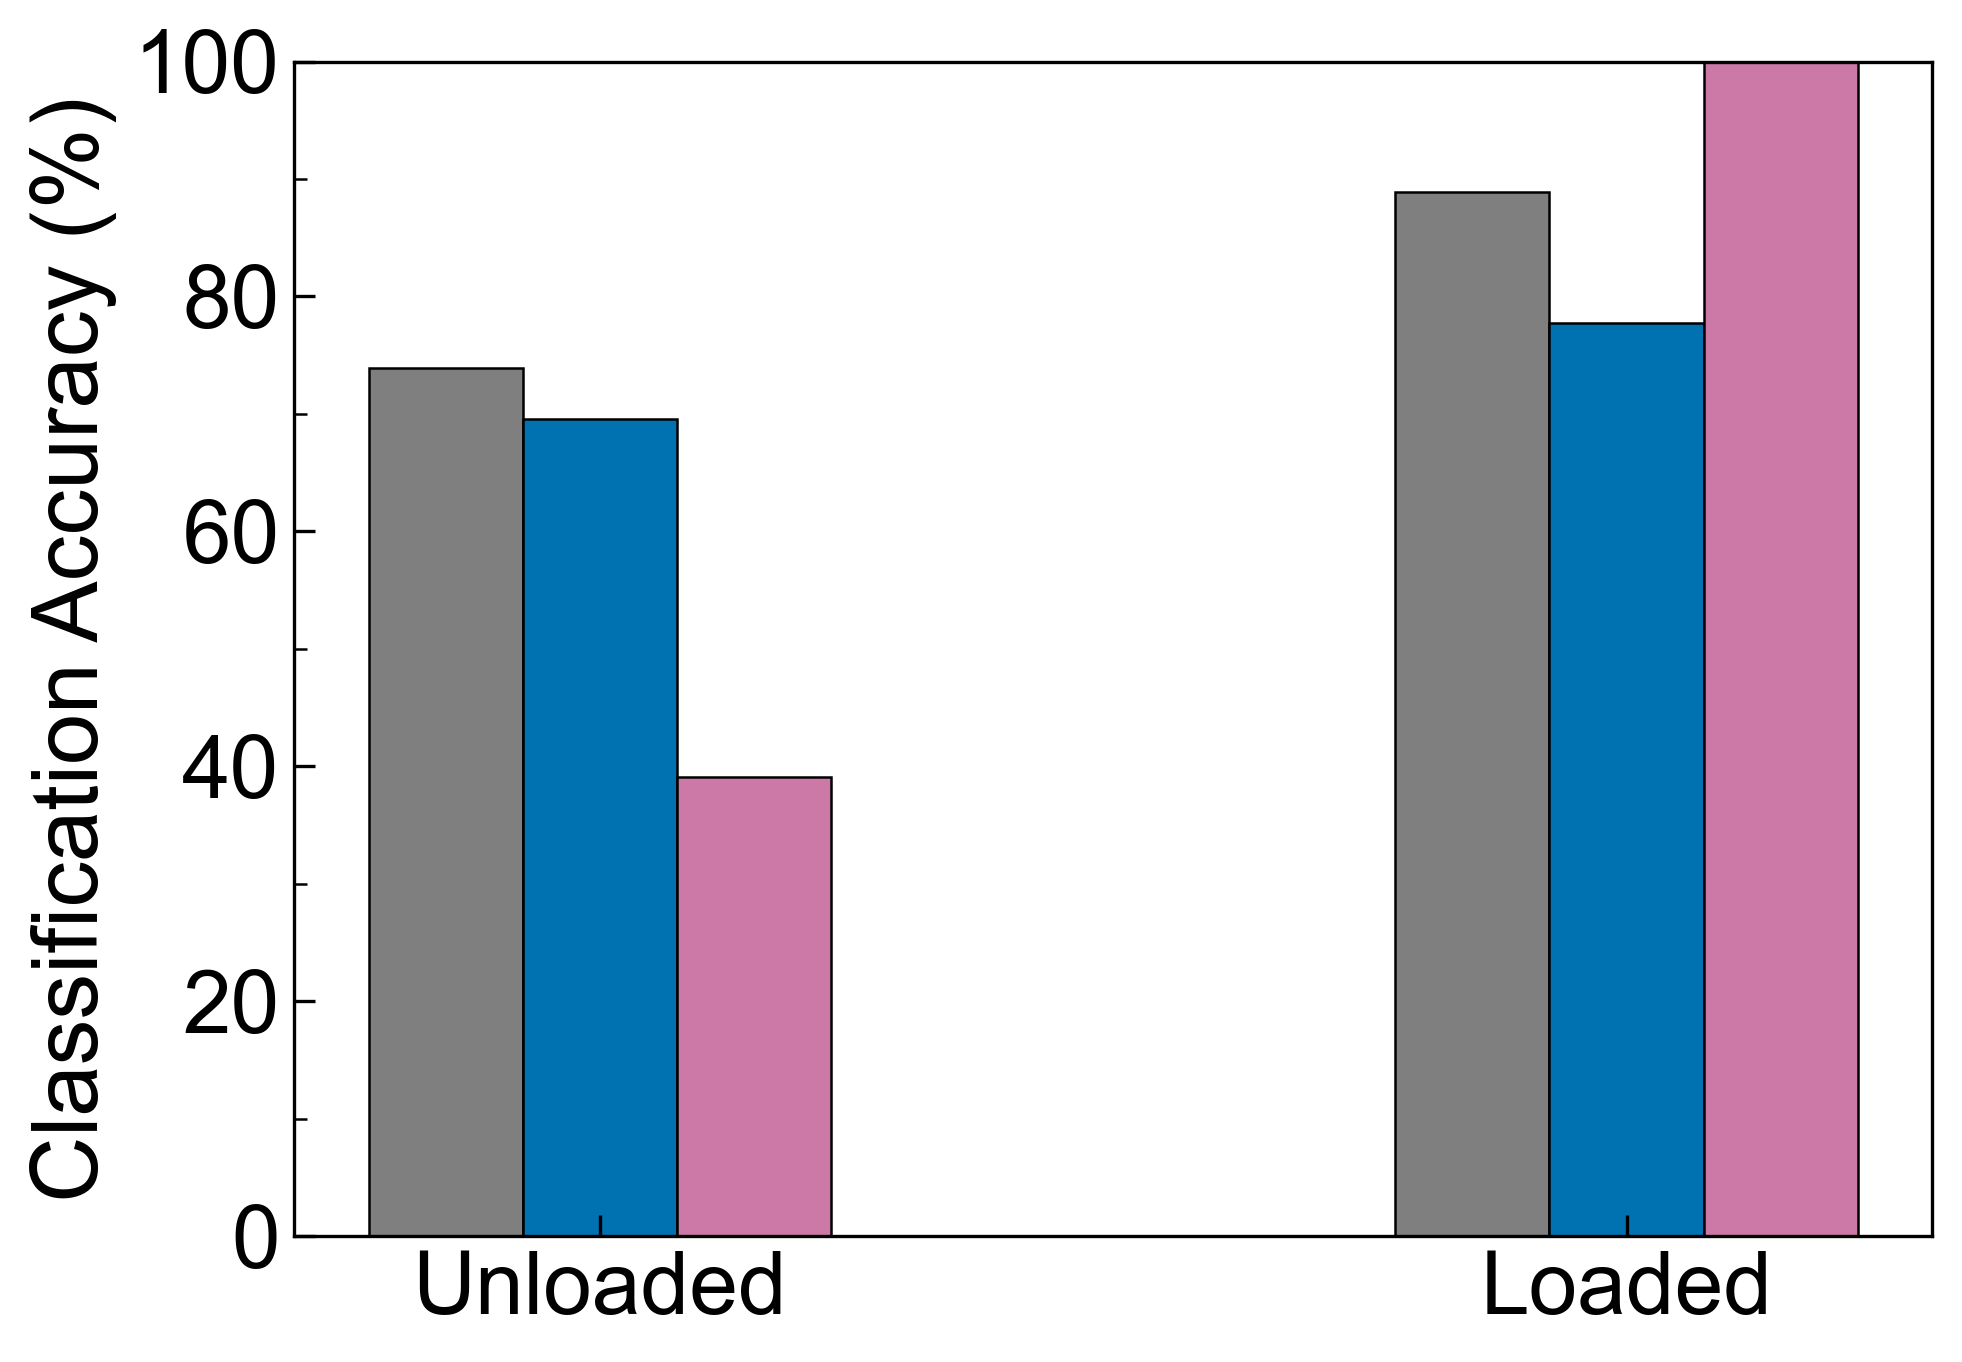

(<Figure size 2100x1500 with 1 Axes>,
 <Axes: ylabel='Classification Accuracy (%)'>)

In [ ]:
interval = [0, 5000, 20000]
tabpfn_cv_acc = [
    [0.8523, 0.00, 0.9041], # interval = 0
    [0.8182, 0.20, 0.9041], # interval = 5000
    [0.6364, 0.40, 0.8767]  # interval = 15000
] # unloaded, near loaded, loaded 

dfm_cv_acc =  [
    [0.6704, 0.00, 0.7534], # interval = 0
    [0.6591, 0.20, 0.7534], # interval = 5000
    [0.3750, 0.60, 0.7260] # interval = 15000
] # unloaded, near loaded, loaded 

qlattice_cv_acc =  [
    [0.4432, 0.00, 0.9726], # interval = 0
    [0.3977, 0.0, 0.9726], # interval = 5000
    [0.1818, 0.60, 0.9315] # interval = 15000
] # unloaded, near loaded, loaded 

xgboost_cv_acc = [
    [0.6705, 0.00, 0.9178], # interval = 0
    [0.6364, 0.20, 0.9178], # interval = 5000
    [0.3750, 0.40, 0.9041] # interval = 15000
] # unloaded, near loaded, loaded 


# best model --------------------
tabpfn_test = [0.7391, 0.0, 0.8889]
dfm_cv_test = [0.6957, 0.0, 0.7778]
qlattice_test = [0.3913, 0, 1]

# Data mapped to the structure in your screenshot
data = {
    'Unloaded': [0.7391, 0.6957, 0.3913],
    'Near L.U': [0.0, 0.0, 0.0],
    'Loaded':   [0.8889, 0.7778, 1.0]
}

# Define the row labels (Index)
models = ['TabPFN model', 'Droplet-Film model', 'Qlattice model']

# Create the DataFrame
per_class_df = pd.DataFrame(data, index=models)

plot_grouped_per_class_accuracy(
    per_class_df,
    palette= MODEL_PALETTE,
    filename="per_class_accuracy_colorblind",
    figsize=(7, 5),
    ylabel="Classification Accuracy (%)",
    family="sans-serif",
    font_size=22,
    mathtext="dejavusans",
)

## Optional alternate CSV analysis (`compariosn_mix2.csv`)

In [16]:
if CSV_ALT.exists():
    alt_palette = {
        "Droplet-Film model": "#0072B2",
        "XGBoost model": "#CC79A7",
        "TabPFN model": "#7F7F7F",
    }
    df_alt = read_comparison_csv(CSV_ALT)
    per_class_df_alt = compute_per_class_accuracy(
        df_alt,
        models=list(alt_palette.keys()),
        delta=15000,
    )
    display(per_class_df_alt)

    plot_grouped_per_class_accuracy(
        per_class_df_alt,
        palette=alt_palette,
        filename="per_class_accuracy_colorblind_alt",
        figsize=(6, 2),
        ylabel="Accuracy (%)",
        family="serif",
        font_size=14,
        mathtext="stix",
    )
else:
    print(f"Optional file not found: {CSV_ALT}")

Optional file not found: compariosn_mix2.csv


## Literature/model comparison plots

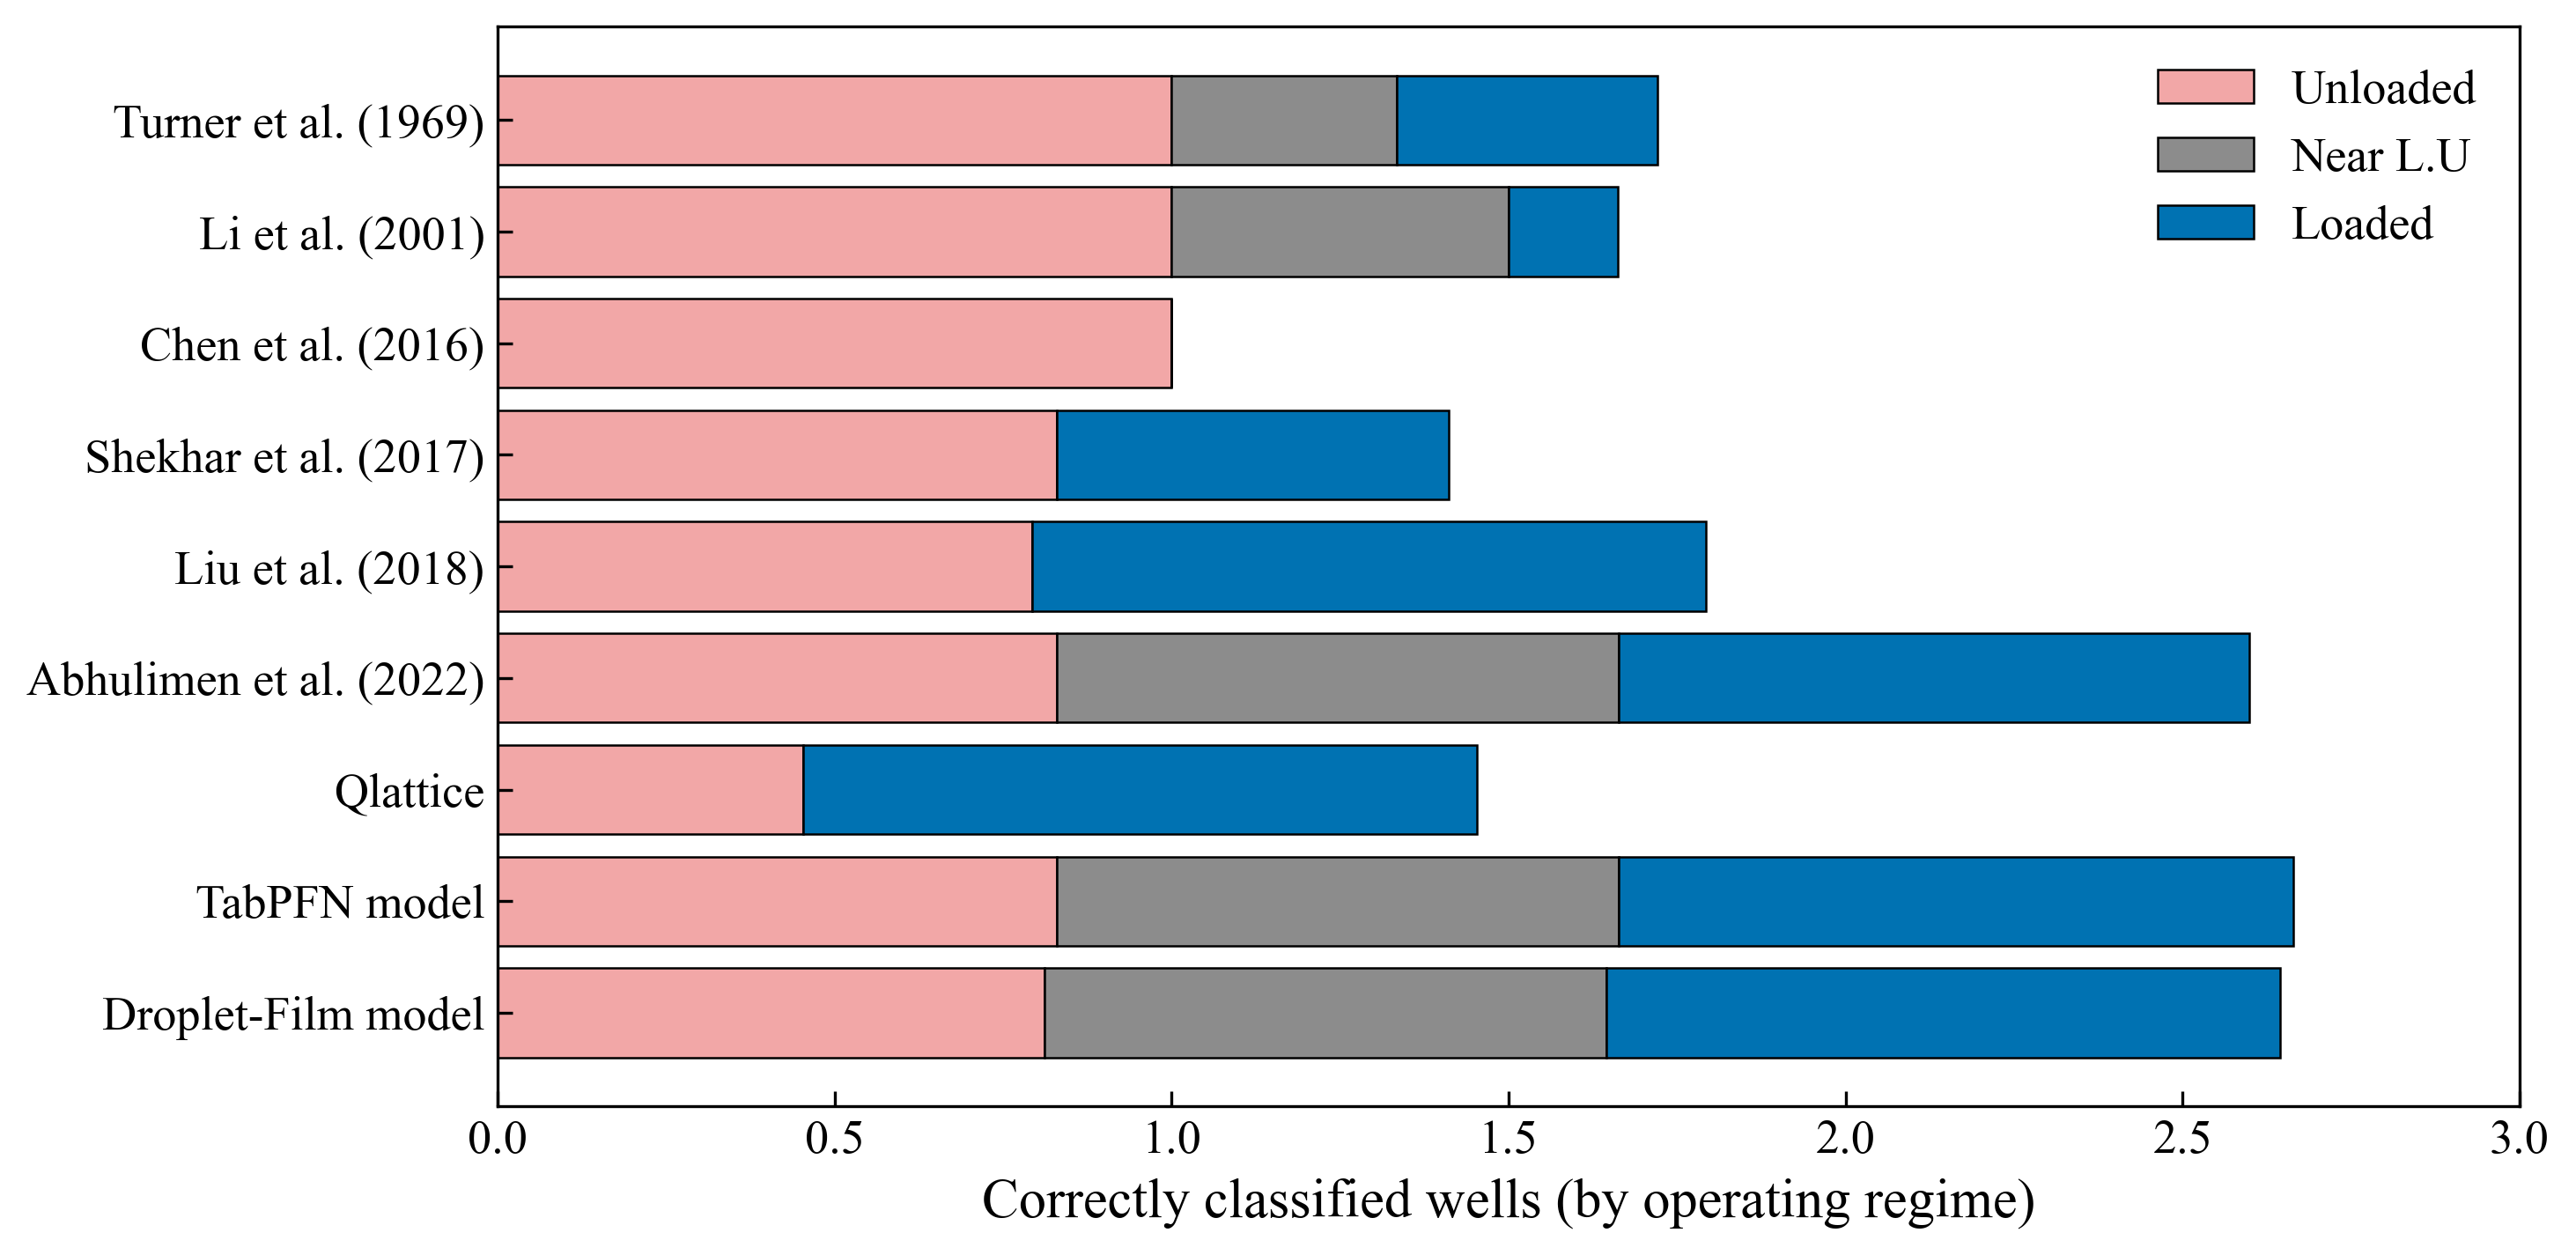

(<Figure size 3000x1500 with 1 Axes>,
 <Axes: xlabel='Correctly classified wells (by operating regime)'>)

In [17]:
plot_stacked_class_performance(
    LITERATURE_PERFORMANCE,
    filename="stacked_class_performance_colorscheme",
    annotate_total_accuracy=False,
    annotate_segment_values=False,
    show_perfect_reference=False,
    xlabel="Correctly classified wells (by operating regime)",
    xlim=(0, 3.0),
    family="serif",
    font_size=15,
    mathtext="stix",
)

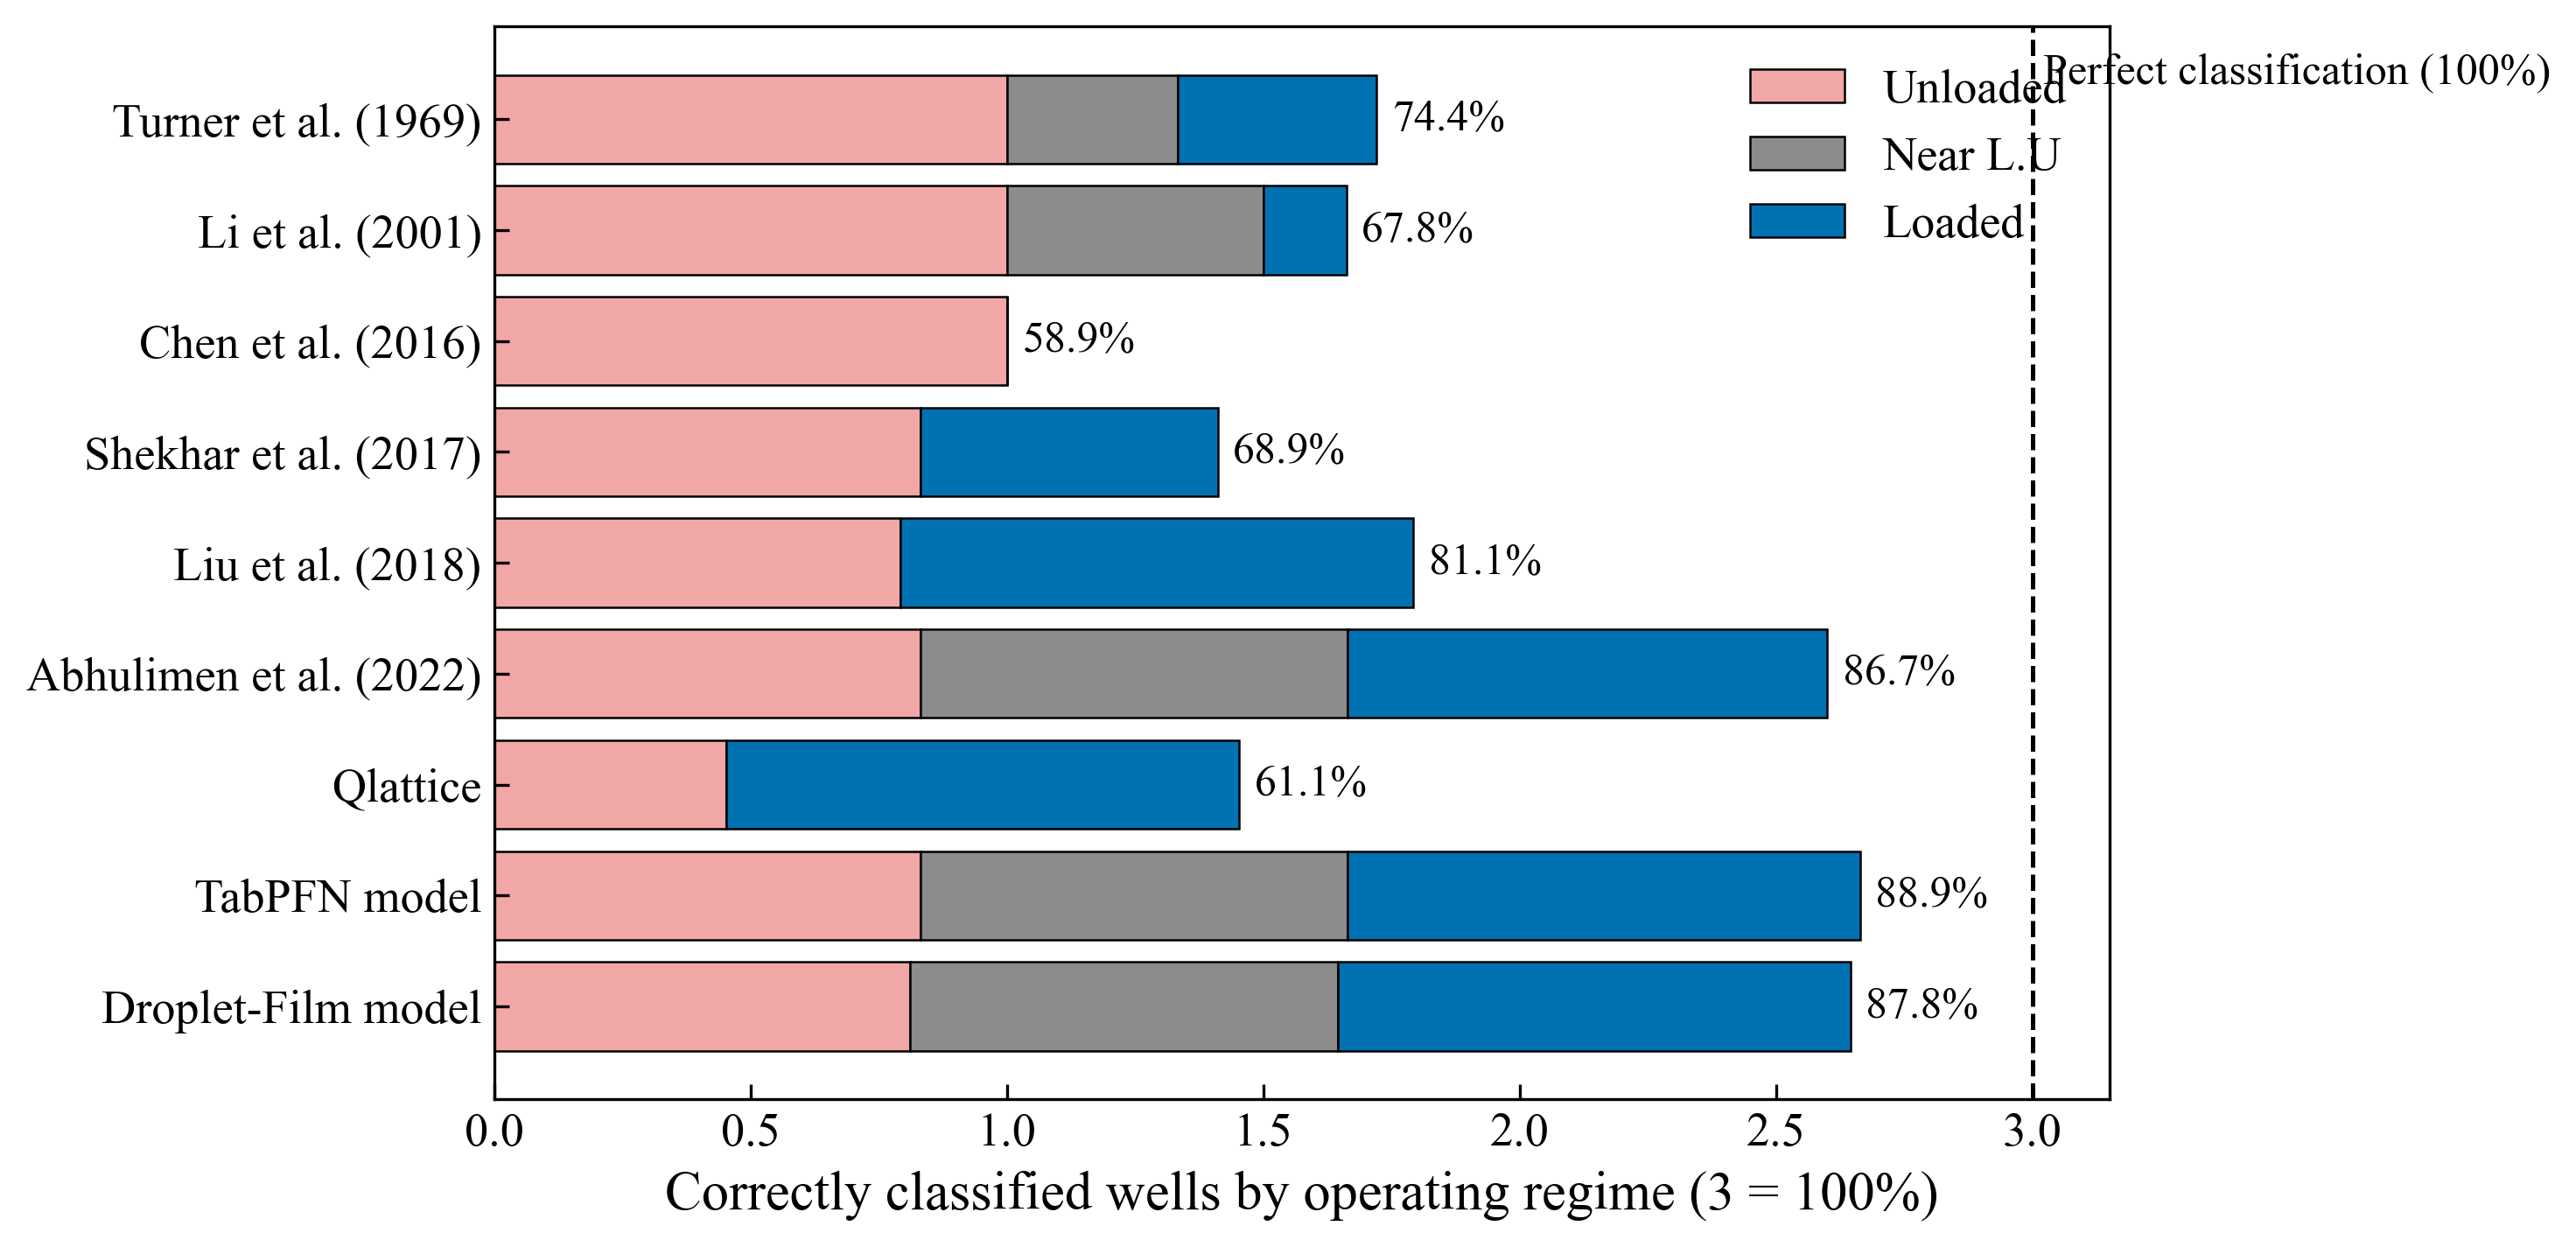

(<Figure size 3000x1500 with 1 Axes>,
 <Axes: xlabel='Correctly classified wells by operating regime (3 = 100%)'>)

In [18]:
plot_stacked_class_performance(
    LITERATURE_PERFORMANCE,
    filename="stacked_class_performance_reviewer_proof",
    annotate_total_accuracy=True,
    annotate_segment_values=False,
    show_perfect_reference=True,
    xlabel="Correctly classified wells by operating regime (3 = 100%)",
    xlim=(0, 3.15),
    family="serif",
    font_size=15,
    mathtext="stix",
)

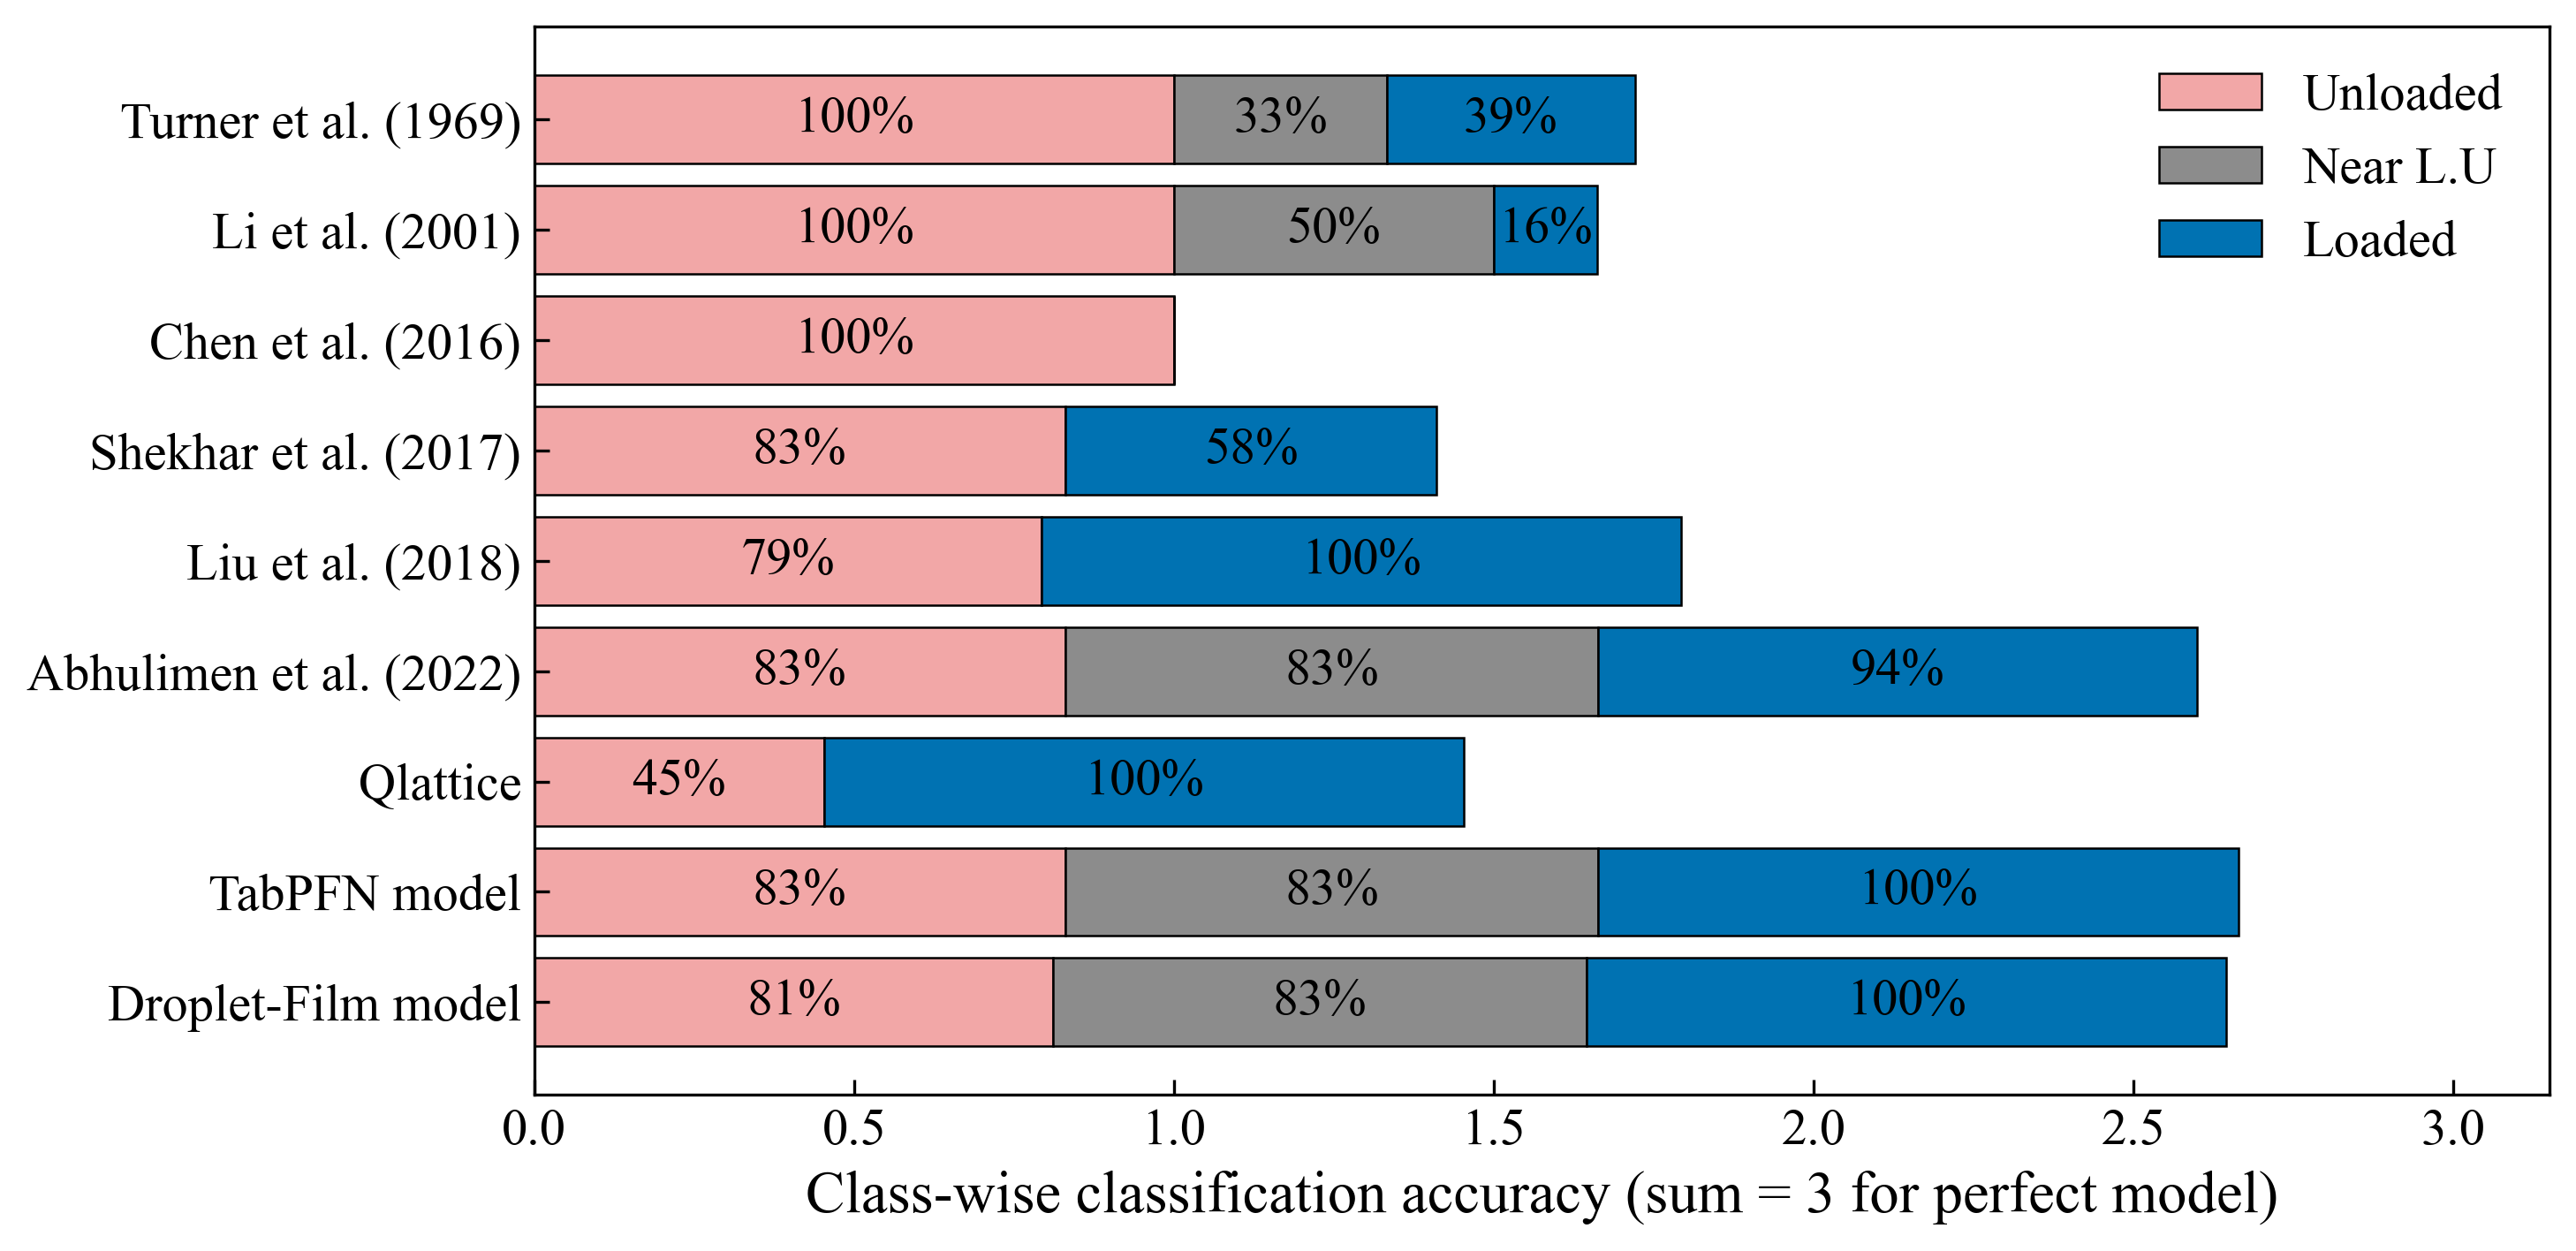

(<Figure size 3000x1500 with 1 Axes>,
 <Axes: xlabel='Class-wise classification accuracy (sum = 3 for perfect model)'>)

In [19]:
plot_stacked_class_performance(
    LITERATURE_PERFORMANCE,
    filename="stacked_classwise_accuracy",
    annotate_total_accuracy=False,
    annotate_segment_values=True,
    show_perfect_reference=False,
    xlabel="Class-wise classification accuracy (sum = 3 for perfect model)",
    xlim=(0, 3.15),
    family="serif",
    font_size=16,
    mathtext="stix",
)

## Cross-validation vs. test accuracy

## Diagnostic table for near-L.U wells

In [20]:
mask = df_main["Well status"] == "Near L.U"
diag_models = ["Droplet-Film model", "Qlattice model", "TabPFN model"]

df_diag = df_main.loc[mask, ["Test flow rate", *diag_models]].copy()
for model in diag_models:
    df_diag[f"{model}_abs_err"] = (df_diag[model] - df_diag["Test flow rate"]).abs()

df_diag.sort_values("TabPFN model_abs_err", ascending=False)

,Test flow rate,Droplet-Film model,Qlattice model,TabPFN model,Droplet-Film model_abs_err,Qlattice model_abs_err,TabPFN model_abs_err
114,45505.17313,479750.150078,107387.457389,25310.620,434244.976948,61882.284259,20194.55313
113,20161.59506,20420.213962,73724.608008,12258.886,258.618902,53563.012948,7902.70906
102,16083.96910,34240.767211,72991.986120,11337.237,18156.798111,56908.017020,4746.73210
106,11808.12520,10650.430259,72559.684000,7381.932,1157.694941,60751.558800,4426.19320
108,12516.04637,12600.883329,72975.728480,8744.745,84.836959,60459.682110,3771.30137
117,21945.55643,23590.030390,110400.451997,19363.846,1644.473960,88454.895567,2581.71043
